In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Iris.csv")

Saving Iris.csv to Iris (1).csv


In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [7]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [8]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

***REMOVING ID COLUMN:***

In [9]:
df = df.drop("Id", axis=1)

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
df.shape

(150, 5)

In [12]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [13]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [15]:
X.shape

(150, 4)

In [16]:
y.shape

(150,)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression(max_iter=200)

In [22]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [23]:
y_pred = model.predict(X_test)

In [24]:
y_pred

array(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa'],
      dtype=object)

In [25]:
y_test.values

array(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa'],
      dtype=object)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
accuracy_score(y_test, y_pred)

0.9666666666666667

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [29]:
model.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

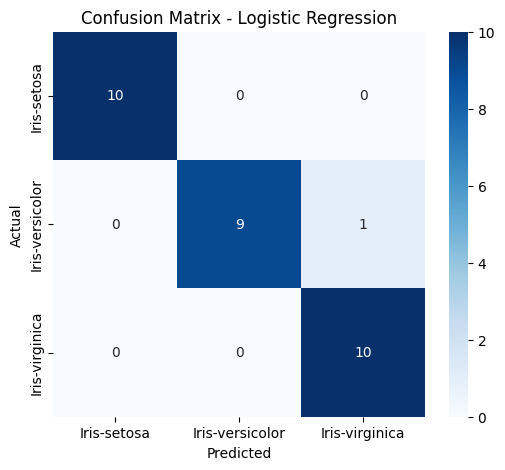

In [30]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

 ***CLASSIFICATION REPORT:***





In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [34]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
knn_pred = knn_model.predict(X_test)

In [37]:
knn_pred

array(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-virginica', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa'],
      dtype=object)

In [38]:
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 100.00%


In [39]:
print(classification_report(y_test, knn_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [43]:
knn_cm = confusion_matrix(y_test, knn_pred)
print(knn_cm)

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


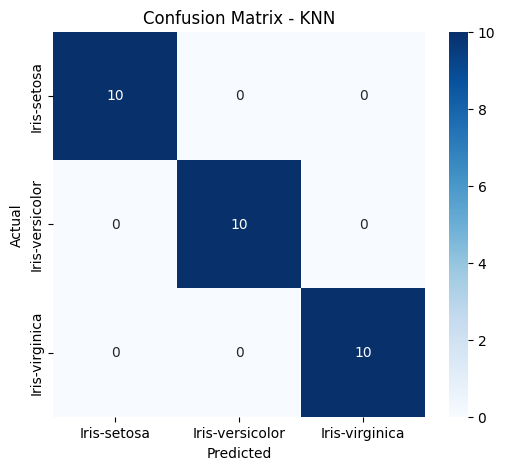

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

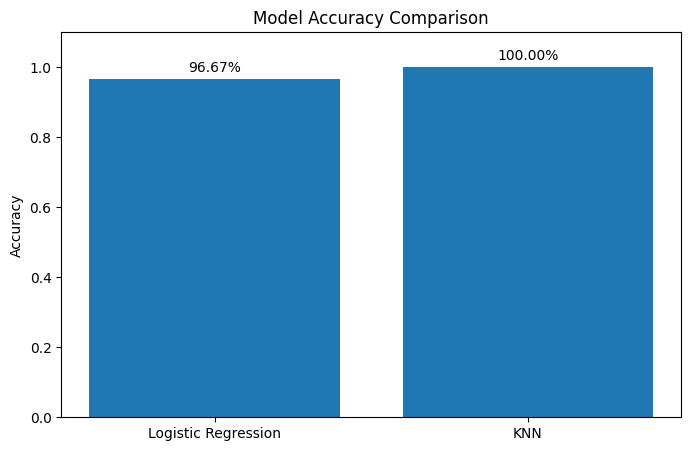

In [46]:
models = ["Logistic Regression", "KNN"]
accuracies = [accuracy_score(y_test, y_pred), accuracy_score(y_test, knn_pred)]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy * 100:.2f}%", ha="center")

plt.show()

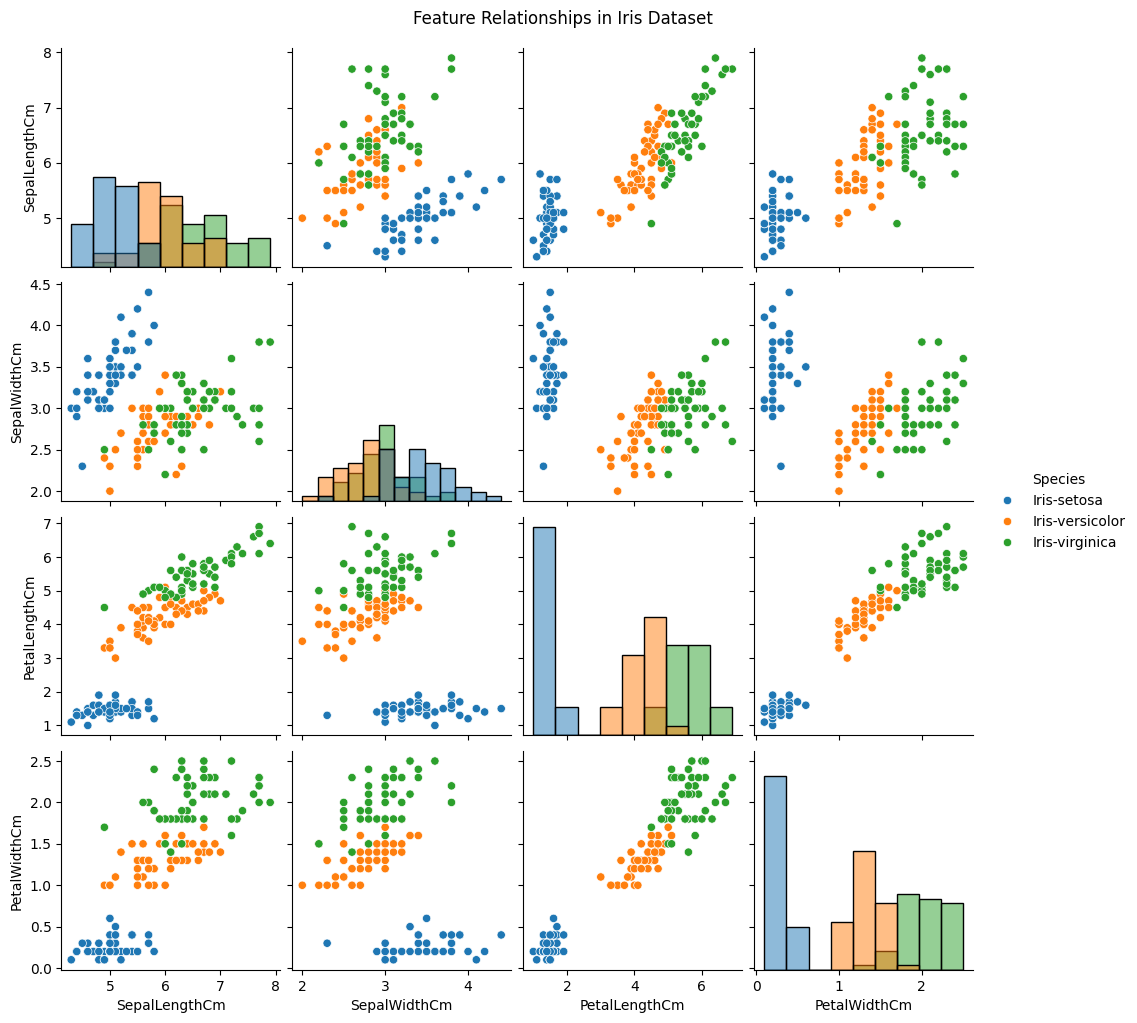

In [47]:
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.suptitle("Feature Relationships in Iris Dataset", y=1.02)
plt.show()

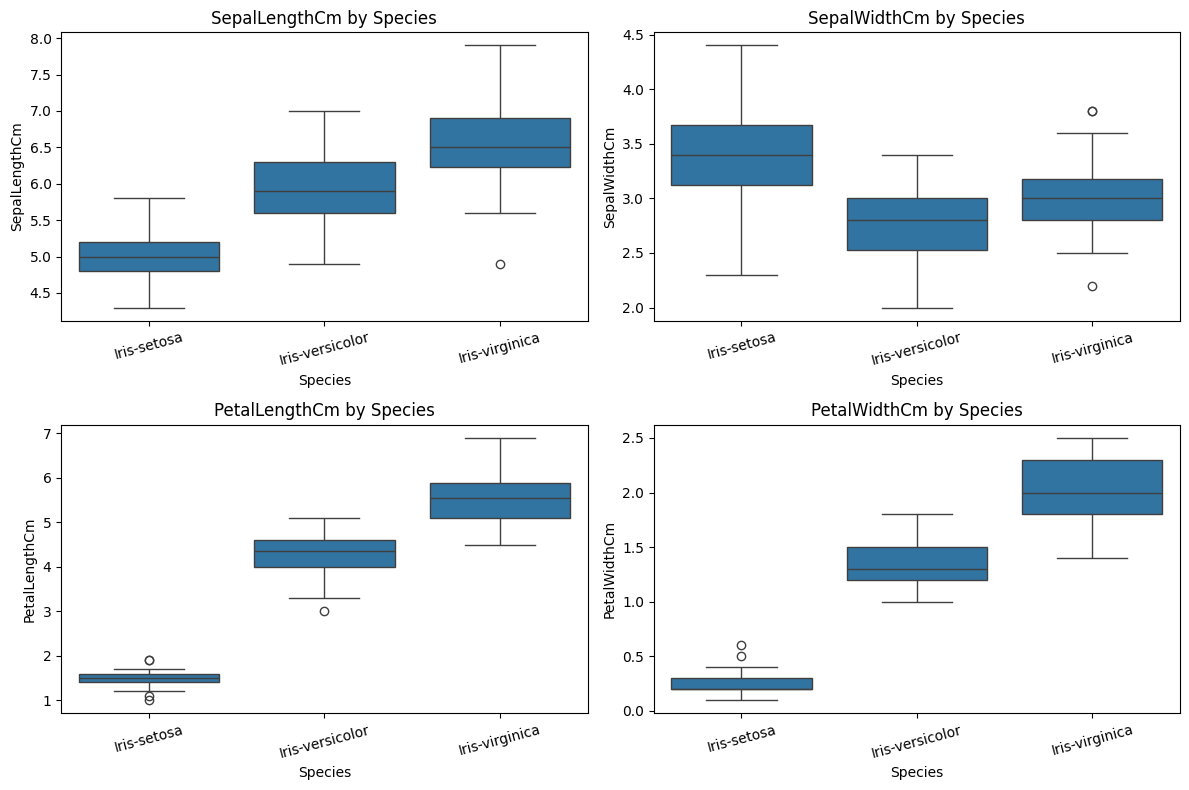

In [48]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(X.columns, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x="Species",
        y=column
    )

    plt.title(f"{column} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# ***Key Insights***

1. **The dataset was well-balanced.**
   The Iris dataset contained 150 samples, with 50 samples belonging to each species: Iris-setosa, Iris-versicolor, and Iris-virginica. This balanced distribution helped reduce the risk of bias toward any particular class during model training.

2. **The dataset contained no missing values.**
   All 150 records had complete values across the available columns. Therefore, no missing-value treatment such as `dropna()` or `fillna()` was required.

3. **Petal measurements were highly useful for classification.**
   Based on the feature visualizations, PetalLengthCm and PetalWidthCm showed strong differences among the three Iris species. These features appeared particularly effective in distinguishing between different flower classes.

4. **Iris-setosa was the easiest species to classify.**
   The visualizations showed that Iris-setosa was relatively well separated from Iris-versicolor and Iris-virginica in terms of its feature measurements.

5. **Iris-versicolor and Iris-virginica showed some overlapping characteristics.**
   These two species had relatively similar measurements in some features. This overlap explains why Logistic Regression misclassified one Iris-versicolor sample as Iris-virginica.

6. **Both machine learning models performed very well.**
   Logistic Regression achieved an accuracy of 96.67%, while K-Nearest Neighbors achieved 100% accuracy on the selected test set.

7. **KNN performed better on the selected test set.**
   Based on the current train-test split, KNN correctly classified all 30 test samples, while Logistic Regression correctly classified 29 out of 30 samples. Therefore, KNN showed the best performance in this particular experiment.

8. **The model comparison demonstrates the importance of testing multiple algorithms.**
   Different machine learning algorithms can produce different results on the same dataset. Comparing multiple models helps identify which algorithm performs better for a specific classification problem.





# ***Conclusion***

This project successfully implemented a complete machine learning workflow for Iris flower species classification using Python and Scikit-learn. The process began with loading and exploring the dataset, followed by checking the dataset structure, data types, class distribution, and missing values.

After removing the unnecessary `Id` column, the four flower measurements — SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm — were used as input features, while Species was selected as the target variable. The dataset was then divided into training and testing sets using an 80/20 split.

Two classification algorithms, Logistic Regression and K-Nearest Neighbors, were trained and evaluated. Logistic Regression achieved an accuracy of 96.67%, while KNN achieved 100% accuracy on the test data. The confusion matrix and classification report provided detailed information about the performance of each model.

The feature visualizations showed that petal measurements were particularly effective in separating the Iris species. Iris-setosa was relatively easy to distinguish, while Iris-versicolor and Iris-virginica had some overlapping characteristics.

Overall, this project demonstrated the complete machine learning pipeline, including data exploration, data preprocessing, feature selection, train-test splitting, model training, prediction, evaluation, visualization, and model comparison. Based on the selected train-test split, KNN performed better than Logistic Regression. However, model performance can vary depending on the train-test split and the characteristics of the data.

This project provided practical experience with classification problems and demonstrated how machine learning models can be trained to classify objects based on their measurable features.
